Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

In [3]:
df = pd.read_csv('./Datasets/calories.csv')
df.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


Drop Non-Informative Column

In [4]:
cols_to_drop = ['User_ID']
df = df.drop(columns=cols_to_drop)
df.shape

(15000, 8)

Handle Duplicates

In [5]:
df.duplicated().sum()

1

In [6]:
if df.duplicated().sum() > 0:
    df = df.drop_duplicates()
len(df)

14999

Handle Missing Value

In [7]:
missing_summary = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percentage': df.isnull().mean() * 100
})

missing_summary
# Kebetulan datasetsnya bersih gada missing value

,missing_count,missing_percentage
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
Duration,0,0.0
Heart_Rate,0,0.0
Body_Temp,0,0.0
Calories,0,0.0


Label Encoding & Feature Engineering

In [8]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
# Female = 0, Male = 1

In [9]:
# Yang gua baca di internet, selain 3 fitur bmr dari berat badan ama tinggi juga pengaruh besar
def calculate_bmr(row):
    if row['Gender'] == 1:
        return (10 * row['Weight']) + (6.25 * row['Height']) - (5 * row['Age']) + 5
    else:
        return (10 * row['Weight']) + (6.25 * row['Height']) - (5 * row['Age']) - 161

df['BMR'] = df.apply(calculate_bmr, axis=1)

In [10]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMR
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0,1792.50
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0,1376.50
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0,1568.75
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0,1497.75
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0,1246.50


EDA

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14999 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      14999 non-null  int32  
 1   Age         14999 non-null  int64  
 2   Height      14999 non-null  float64
 3   Weight      14999 non-null  float64
 4   Duration    14999 non-null  float64
 5   Heart_Rate  14999 non-null  float64
 6   Body_Temp   14999 non-null  float64
 7   Calories    14999 non-null  float64
 8   BMR         14999 non-null  float64
dtypes: float64(7), int32(1), int64(1)
memory usage: 1.1 MB


In [12]:
df.describe()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories,BMR
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.496500,42.790786,174.465831,74.967931,15.531035,95.518901,40.025488,89.542836,1547.555787
std,0.500004,16.980401,14.258333,15.035593,8.319310,9.583542,0.779244,62.457750,312.891606
min,0.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000,692.750000
25%,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000,1284.000000
50%,0.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000,1534.000000
75%,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000,1810.000000
max,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000,2562.500000


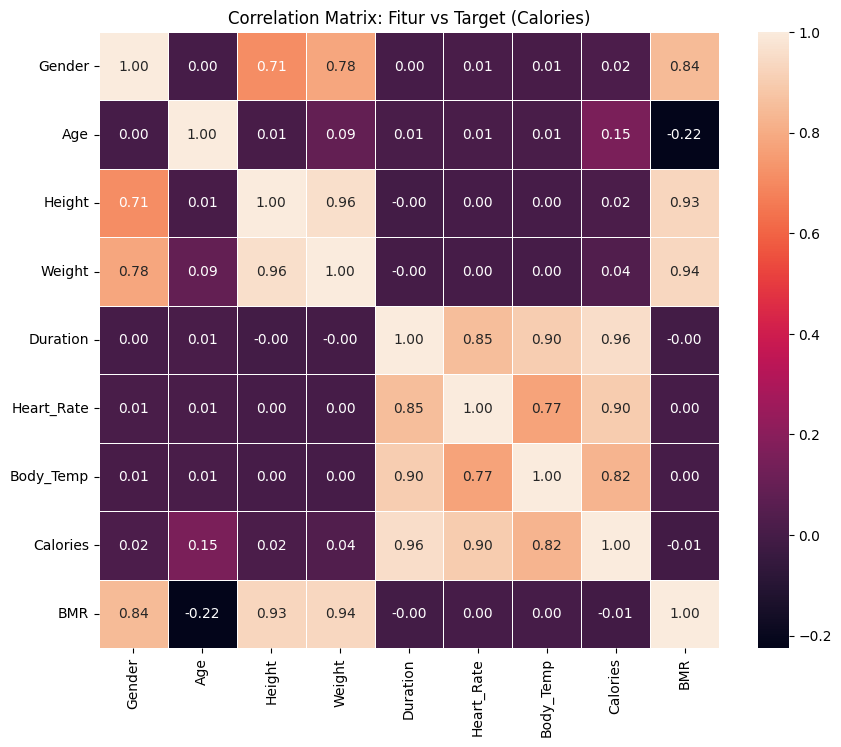

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Fitur vs Target (Calories)")
plt.show()

Feature Selection

In [14]:
features = ['Age', 'Heart_Rate', 'Duration', 'BMR']
X = df[features]
y = df['Calories']

Data Splitting

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Jumlah Training Data: {X_train.shape[0]}")
print(f"Jumlah Testing Data: {X_test.shape[0]}")

Jumlah Training Data: 11999
Jumlah Testing Data: 3000


Modeling Random Forest Regressor

In [16]:
rf_base = RandomForestRegressor(random_state=42)
rf_base.fit(X_train, y_train)
y_pred_base = rf_base.predict(X_test)

Evaluation Metrics

In [17]:
print("\n=== Evaluasi Base Model Random Forest ===")
print(f"MAE  : {mean_absolute_error(y_test, y_pred_base):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_base)):.4f}")
print(f"R²   : {r2_score(y_test, y_pred_base):.4f}")


=== Evaluasi Base Model Random Forest ===
MAE  : 1.9493
RMSE : 3.4495
R²   : 0.9969


Ini model paling bagus jadinya kita export

In [18]:
import joblib
joblib.dump(rf_base, './Model/rf_model.sav', compress=3)

print("Model berhasil dikompresi dan disimpan sebagai rf_model.sav!")

Model berhasil dikompresi dan disimpan sebagai rf_model.sav!
